<a href="https://colab.research.google.com/github/hyeonggyeong-kim/comprehensive-project/blob/khg/ml/experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 크기: (95602, 19)

Driving Score Distribution:
count    95602.000000
mean        94.261152
std         10.827998
min         12.800000
25%         93.300000
50%        100.000000
75%        100.000000
max        100.000000
Name: DRIVING_SCORE, dtype: float64
DRIVING_SCORE
safe(81~100)        84752
normal(41~80)       10809
aggressive(0~40)       41
Name: count, dtype: int64


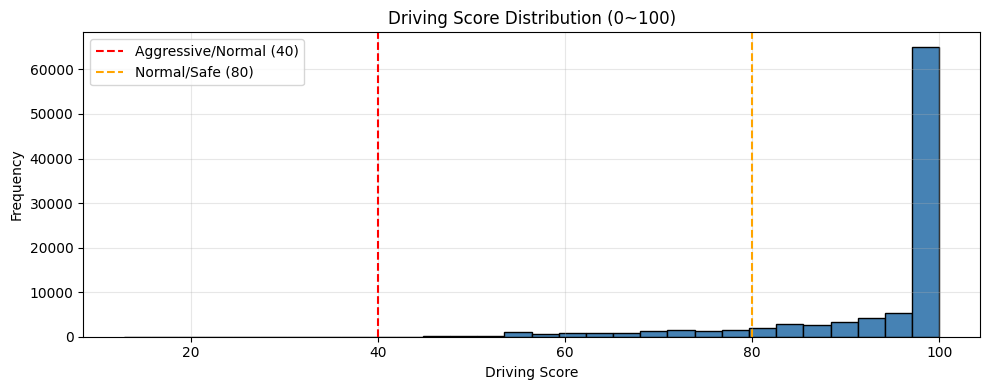


사용 피처 (15개): ['SPEED', 'ENGINE_RPM', 'THROTTLE_POS', 'ENGINE_LOAD', 'ENGINE_COOLANT_TEMP', 'AIR_INTAKE_TEMP', 'TIMING_ADVANCE', 'SPEED_DIFF', 'RPM_DIFF', 'THROTTLE_DIFF', 'SPEED_MA', 'RPM_MA', 'RPM_STD', 'THROTTLE_MA', 'THROTTLE_STD']
X_train: (76481, 15) | X_test: (19121, 15)
결측치 확인:
Series([], dtype: int64)

결측치 처리 후: 0개

===== Ridge =====
MAE:4.8784 MSE:60.0953 RMSE:7.7521 R²:0.4699

===== Lasso =====
MAE:5.0953 MSE:63.4868 RMSE:7.9679 R²:0.4400

===== ElasticNet =====
MAE:5.1595 MSE:65.0259 RMSE:8.0639 R²:0.4265

===== DecisionTree =====
MAE:1.0327 MSE:6.1737 RMSE:2.4847 R²:0.9455

===== RandomForest =====
MAE:0.7692 MSE:2.8975 RMSE:1.7022 R²:0.9744

===== ExtraTrees =====
MAE:0.8172 MSE:3.1233 RMSE:1.7673 R²:0.9725

===== AdaBoost =====
MAE:6.5103 MSE:47.7317 RMSE:6.9088 R²:0.5790

===== GradBoost =====
MAE:1.1291 MSE:4.6804 RMSE:2.1634 R²:0.9587

===== SVR_RBF =====
MAE:1.1951 MSE:6.5865 RMSE:2.5664 R²:0.9419

===== SVR_Poly =====
MAE:2.3200 MSE:61.1795 RMSE:7.8217 R²:0.4604

==

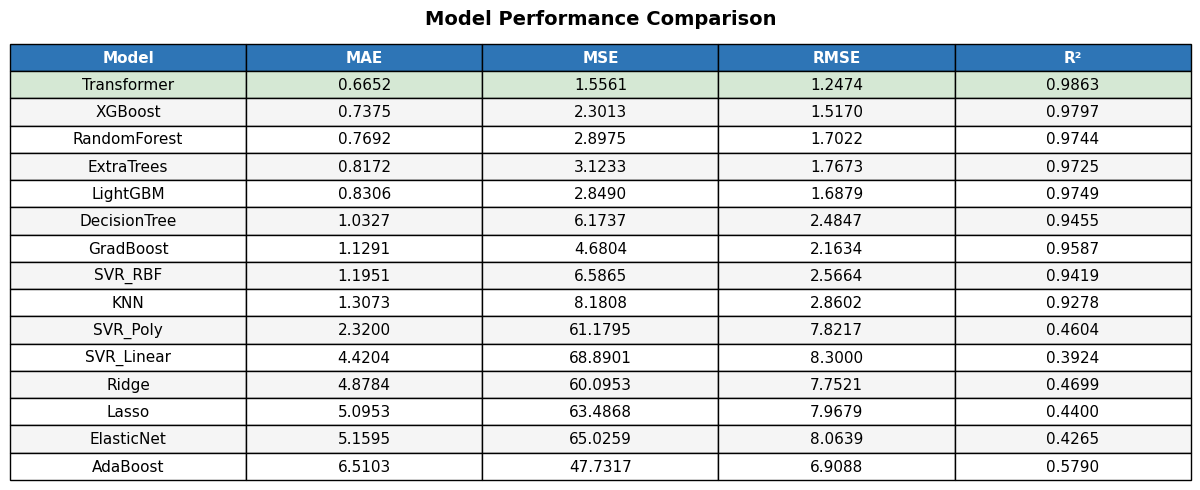

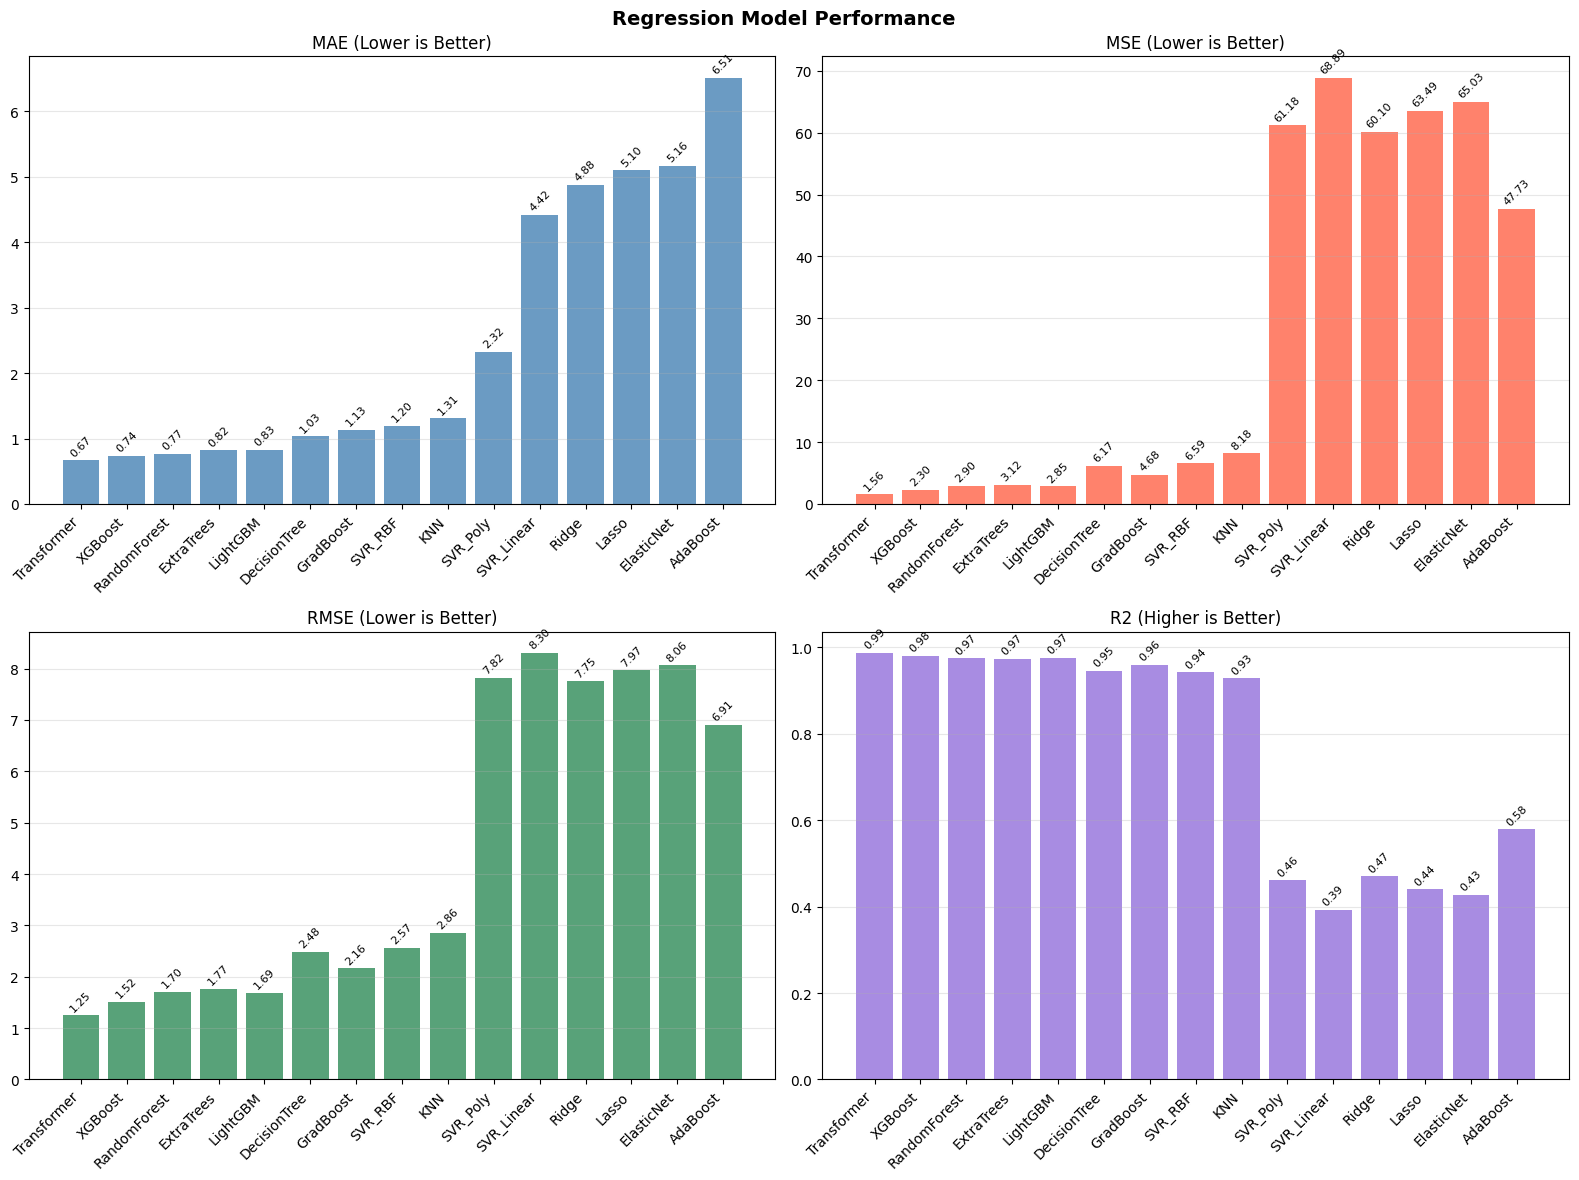


===== 5-Fold Cross Validation (RandomForest) =====
Fold          MAE        MSE     RMSE       R²
--------------------------------------------------
Fold 1     0.7713     2.9028   1.7038   0.9744
Fold 2     0.7760     2.9756   1.7250   0.9746
Fold 3     0.7755     2.9697   1.7233   0.9754
Fold 4     0.7565     2.8643   1.6924   0.9753
Fold 5     0.7744     2.9704   1.7235   0.9750
--------------------------------------------------
Mean       0.7707     2.9366   1.7136   0.9749
Std        0.0073     0.0450   0.0132   0.0004


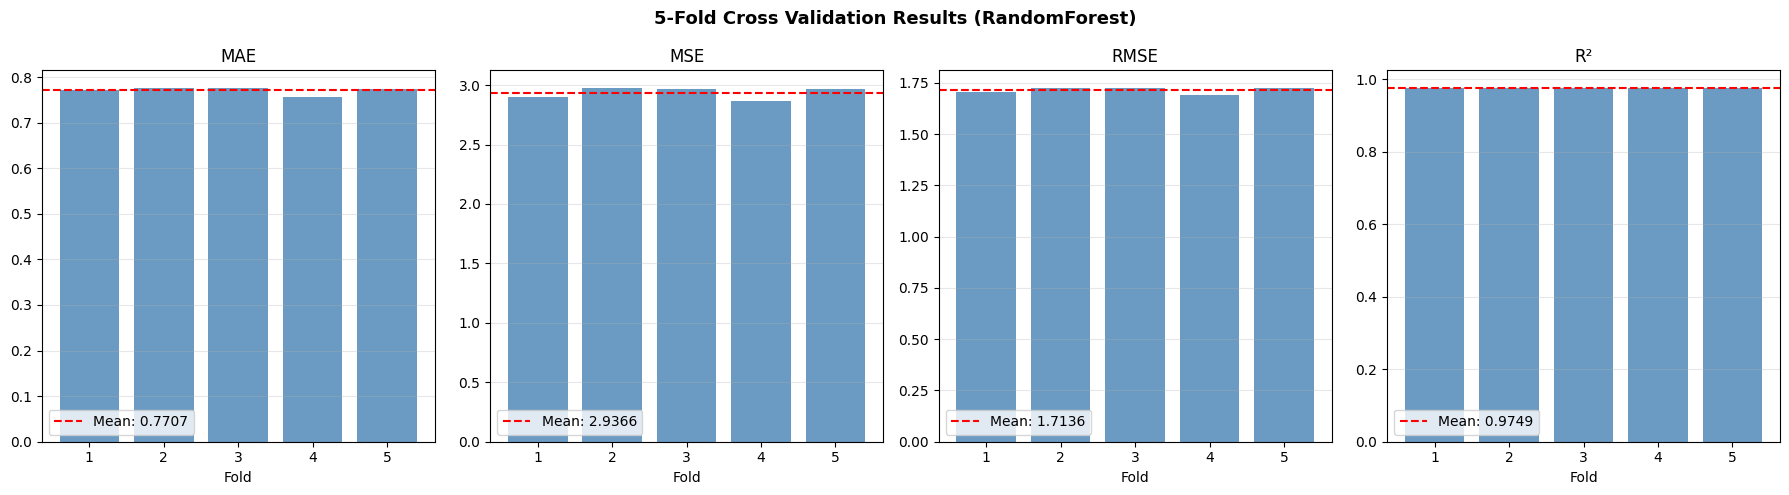


===== Before Tuning =====
n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1
MAE: 0.7713
MSE: 2.9213
RMSE: 1.7092
R2: 0.9742
Fitting 3 folds for each of 10 candidates, totalling 30 fits

===== After Tuning =====
Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
MAE: 0.7695
MSE: 2.9019
RMSE: 1.7035
R2: 0.9744

===== Tuning Effect =====
Metric   Before    After  Improvement
----------------------------------------
MAE      0.7713   0.7695      +0.0018
MSE      2.9213   2.9019      +0.0194
RMSE     1.7092   1.7035      +0.0057
R2       0.9742   0.9744      +0.0002


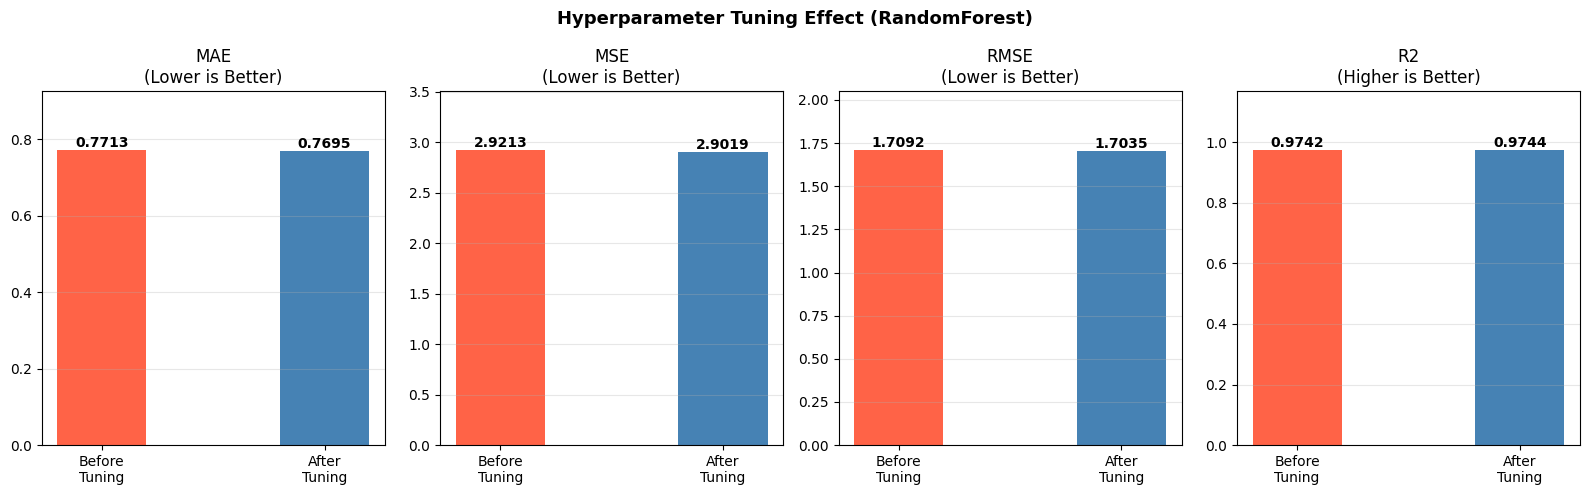


===== Hyperparameter Combinations (Sorted by MAE) =====
Rank   n_est    depth  split  leaf      MAE
---------------------------------------------
1        200     None      2     2   0.8120 <- Best
2        200     None      2     1   0.8123
3        100     None      2     1   0.8141
4        200       20      2     2   0.8247
5        100       20      2     1   0.8264
6        100       20      5     1   0.8288
7        200       10      2     2   1.0437
8        200       10      2     1   1.0445
9        200       10      5     1   1.0449
10       100       10      2     1   1.0453


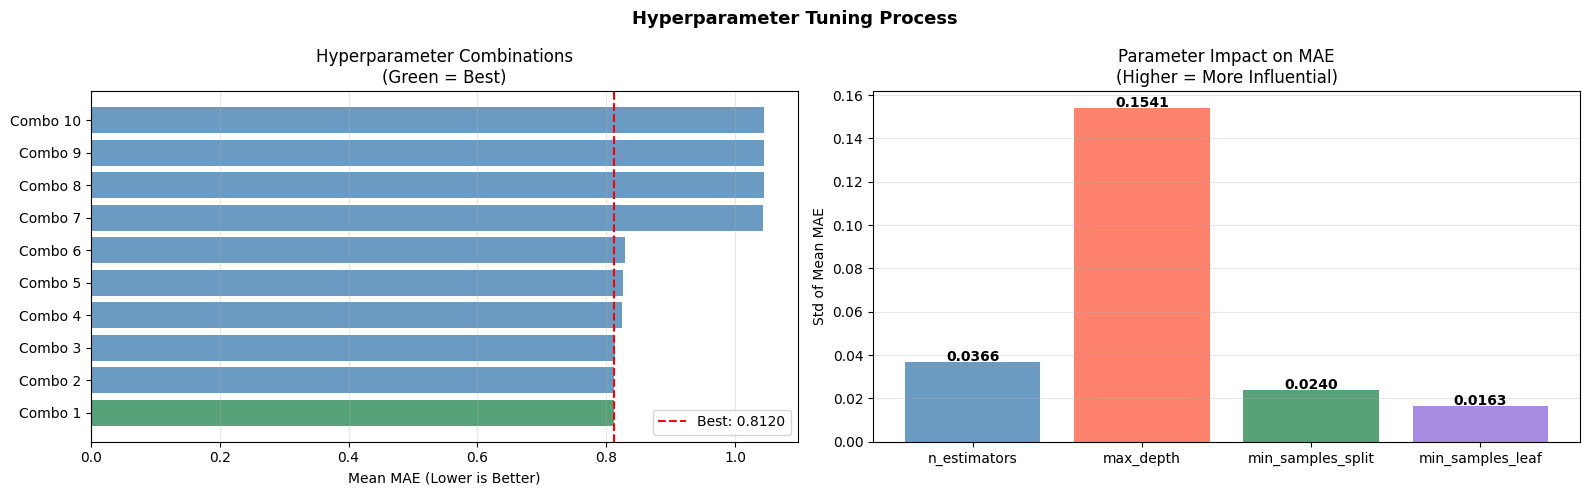


===== Ensemble Model Comparison =====
Model                       MAE        MSE     RMSE       R²
------------------------------------------------------------
RandomForest             0.7695     2.9019   1.7035   0.9744
XGBoost                  0.7375     2.3013   1.5170   0.9797
RF + XGBoost Ensemble    0.7132     2.3163   1.5219   0.9796


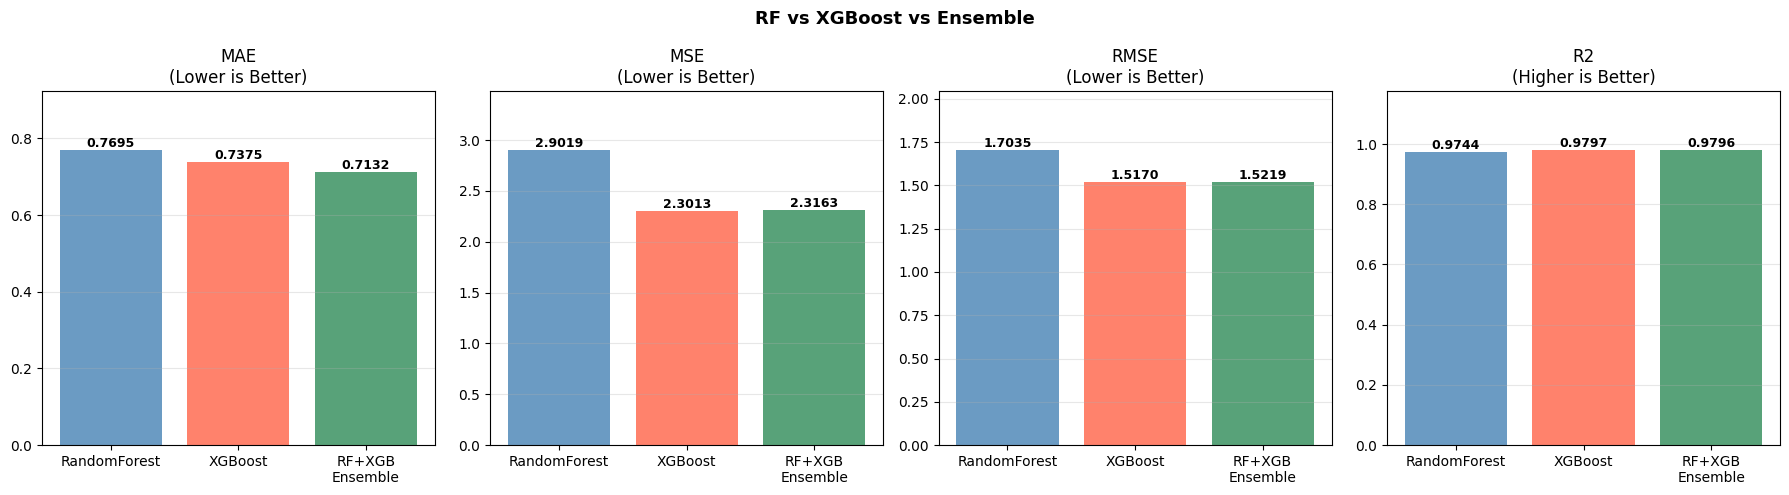

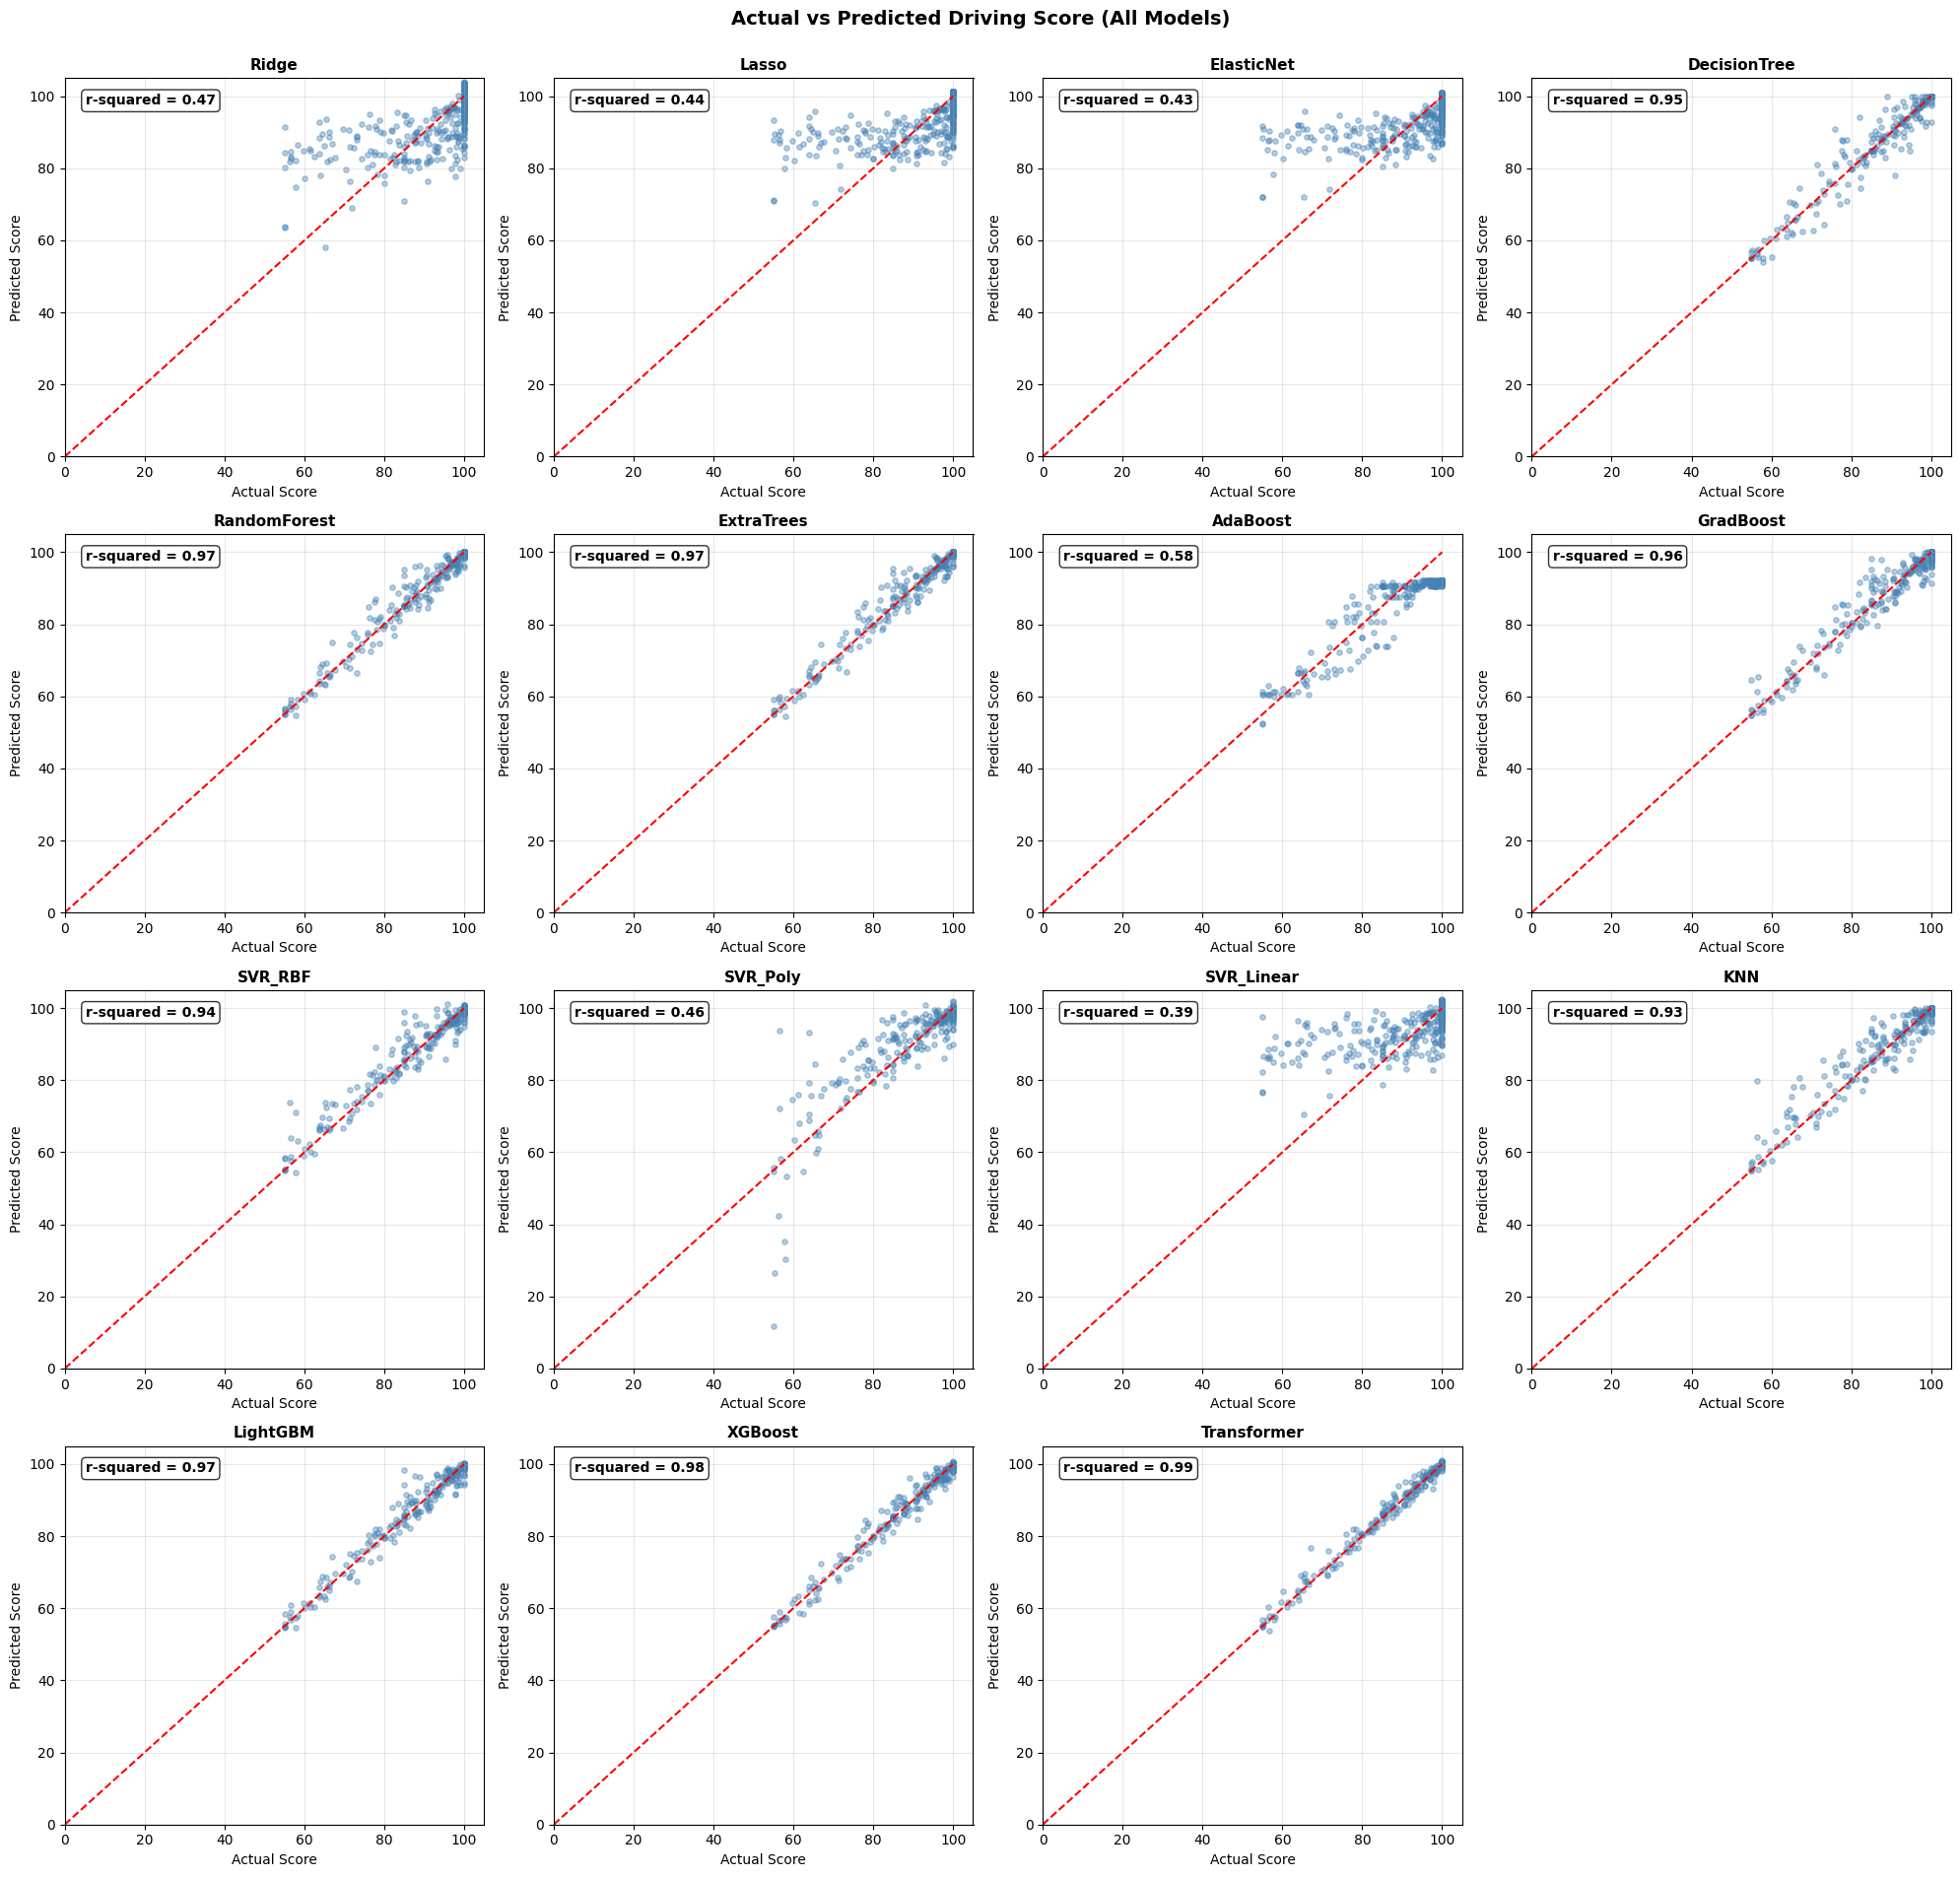

In [ ]:
# =========================
# 폰트 설정
# =========================

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# PART 1. 라이브러리
# =========================

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import ExtraTreesRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor,
    VotingRegressor
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    RandomizedSearchCV
)
from sklearn.impute import SimpleImputer

# =========================
# PART 2. 데이터 불러오기
# =========================

import pandas as pd

df = pd.read_csv('obd_all_merged.csv')
print("데이터 크기:", df.shape)

# =========================
# PART 3. 운전 점수 산출
# =========================

def calculate_driving_score(row):
    score = 100
    if "SPEED_DIFF" in row:
        accel = max(0, row["SPEED_DIFF"] - 5)
        score -= min(30, accel * 1.5)
        brake = max(0, -row["SPEED_DIFF"] - 5)
        score -= min(30, brake * 1.5)
    if "ENGINE_RPM" in row and row["ENGINE_RPM"] > 2500:
        rpm_excess = (row["ENGINE_RPM"] - 2500) / 100
        score -= min(20, rpm_excess * 2)
    if "SPEED" in row and row["SPEED"] > 80:
        speed_excess = row["SPEED"] - 80
        score -= min(25, speed_excess * 0.5)
    if "SPEED_STD" in row and row["SPEED_STD"] > 5:
        score -= min(15, (row["SPEED_STD"] - 5) * 1.0)
    return max(0, round(score, 1))

df["DRIVING_SCORE"] = df.apply(calculate_driving_score, axis=1)

print("\nDriving Score Distribution:")
print(df["DRIVING_SCORE"].describe())
print(pd.cut(df["DRIVING_SCORE"],
             bins=[-1, 40, 80, 100],
             labels=["aggressive(0~40)", "normal(41~80)", "safe(81~100)"]
             ).value_counts())

# 점수 분포 시각화
plt.figure(figsize=(10, 4))
plt.hist(df["DRIVING_SCORE"], bins=30, color="steelblue", edgecolor="black")
plt.axvline(x=40, color='red',    linestyle='--', label='Aggressive/Normal (40)')
plt.axvline(x=80, color='orange', linestyle='--', label='Normal/Safe (80)')
plt.title("Driving Score Distribution (0~100)")
plt.xlabel("Driving Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# PART 4. X, y 분리
# =========================

target_col = "DRIVING_SCORE"

drop_cols = [
    "TIMESTAMP", target_col, "DRIVING_STYLE",
    "HARSH_ACCEL", "HARSH_BRAKE", "HIGH_RPM", "HIGH_SPEED", "IDLING",
    "SPEED_STD",
    "HARSH_ACCEL_CUMSUM", "HARSH_BRAKE_CUMSUM",
    "HIGH_RPM_CUMSUM", "HIGH_SPEED_CUMSUM", "IDLING_CUMSUM",
    "DATA_SOURCE"
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

print(f"\n사용 피처 ({X.shape[1]}개): {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# =========================
# PART 4-1. 결측치 처리 (X 분리 전)
# =========================

from sklearn.impute import SimpleImputer

print("결측치 확인:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# 수치형 컬럼 결측치 중앙값으로 대체
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\n결측치 처리 후: {X.isnull().sum().sum()}개")

# =========================
# PART 5. 15개 모델 비교
# =========================

models = {
    "Ridge":         Ridge(random_state=42),
    "Lasso":         Lasso(random_state=42),
    "ElasticNet":    ElasticNet(random_state=42),
    "DecisionTree":  DecisionTreeRegressor(random_state=42),
    "RandomForest":  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "ExtraTrees":    ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "AdaBoost":      AdaBoostRegressor(random_state=42),
    "GradBoost":     GradientBoostingRegressor(random_state=42),
    "SVR_RBF":       SVR(kernel='rbf'),
    "SVR_Poly":      SVR(kernel='poly'),
    "SVR_Linear":    SVR(kernel='linear'),
    "KNN":           KNeighborsRegressor(n_jobs=-1),
    "LightGBM":      LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost":       XGBRegressor(random_state=42, n_jobs=-1),
    "Transformer":   MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

# 스케일링이 필수인 모델들
scaled_models = ["Ridge", "Lasso", "ElasticNet", "SVR_RBF", "SVR_Poly", "SVR_Linear", "KNN", "Transformer"]

results = []
trained_models = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")

    # 모델 특성에 맞춰 데이터 분기
    X_tr = X_train_sc if model_name in scaled_models else X_train
    X_te = X_test_sc  if model_name in scaled_models else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results.append({"Model": model_name,
                     "MAE": round(mae,4), "MSE": round(mse,4),
                     "RMSE": round(rmse,4), "R2": round(r2,4)})
    trained_models[model_name] = model

    print(f"MAE:{mae:.4f} MSE:{mse:.4f} RMSE:{rmse:.4f} R²:{r2:.4f}")

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
print("\n===== Model Comparison =====")
print(results_df.to_string(index=False))

# 성능 비교 표 시각화 (기존과 동일)
fig, ax = plt.subplots(figsize=(12, 5)) # 15개로 늘어나서 세로폭을 조금 늘렸습니다 (4->5)
ax.axis('off')
col_labels = ["Model", "MAE", "MSE", "RMSE", "R²"]
table_data = [[r["Model"], f"{r['MAE']:.4f}", f"{r['MSE']:.4f}",
               f"{r['RMSE']:.4f}", f"{r['R2']:.4f}"] for _, r in results_df.iterrows()]

table = ax.table(cellText=table_data, colLabels=col_labels,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5) # 표 간격 조정
for col in range(len(col_labels)):
    table[0, col].set_facecolor("#2E75B6")
    table[0, col].set_text_props(color="white", fontweight="bold")
for col in range(len(col_labels)):
    table[1, col].set_facecolor("#D5E8D4")
for row_idx in range(2, len(table_data)+1):
    color = "#F5F5F5" if row_idx % 2 == 0 else "white"
    for col in range(len(col_labels)):
        fc = table[row_idx, col].get_facecolor()
        if round(fc[0], 2) == 0.84:
            continue
        table[row_idx, col].set_facecolor(color)
plt.title("Model Performance Comparison", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# 막대그래프 시각화 (기존과 동일)
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 텍스트가 겹치지 않게 세로폭 살짝 증가
x = range(len(results_df))

for ax, (metric, color, note) in zip(axes.flatten(), [
    ("MAE",  "steelblue",   "Lower is Better"),
    ("MSE",  "tomato",      "Lower is Better"),
    ("RMSE", "seagreen",    "Lower is Better"),
    ("R2",   "mediumpurple","Higher is Better"),
]):
    bars = ax.bar(x, results_df[metric], color=color, alpha=0.8)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(results_df[metric])*0.01,
                f"{val:.2f}", ha='center', fontsize=8, rotation=45) # 폰트 크기 줄이고 회전
    ax.set_title(f"{metric} ({note})")
    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Model"], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Regression Model Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================
# PART 6. 교차검증 (5-Fold)
# =========================

print("\n===== 5-Fold Cross Validation (RandomForest) =====")

rf_cv = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae  = cross_val_score(rf_cv, X, y, cv=cv, scoring="neg_mean_absolute_error")
cv_mse  = cross_val_score(rf_cv, X, y, cv=cv, scoring="neg_mean_squared_error")
cv_r2   = cross_val_score(rf_cv, X, y, cv=cv, scoring="r2")
cv_rmse = np.sqrt(-cv_mse)

print(f"{'Fold':<8} {'MAE':>8} {'MSE':>10} {'RMSE':>8} {'R²':>8}")
print("-"*50)
for i in range(5):
    print(f"Fold {i+1:<3} {-cv_mae[i]:>8.4f} {-cv_mse[i]:>10.4f} {cv_rmse[i]:>8.4f} {cv_r2[i]:>8.4f}")
print("-"*50)
print(f"{'Mean':<8} {-cv_mae.mean():>8.4f} {-cv_mse.mean():>10.4f} {cv_rmse.mean():>8.4f} {cv_r2.mean():>8.4f}")
print(f"{'Std':<8} {cv_mae.std():>8.4f} {cv_mse.std():>10.4f} {cv_rmse.std():>8.4f} {cv_r2.std():>8.4f}")

# 교차검증 시각화
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (title, scores) in zip(axes, [
    ("MAE",  -cv_mae),
    ("MSE",  -cv_mse),
    ("RMSE", cv_rmse),
    ("R²",   cv_r2),
]):
    ax.bar(range(1,6), scores, color="steelblue", alpha=0.8)
    ax.axhline(y=scores.mean(), color="red", linestyle="--",
               label=f"Mean: {scores.mean():.4f}")
    ax.set_title(f"{title}")
    ax.set_xlabel("Fold")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("5-Fold Cross Validation Results (RandomForest)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================
# PART 7. 하이퍼파라미터 튜닝
# =========================

param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [1, 2]
}

# 튜닝 전 기본 성능
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
before = {
    "MAE":  mean_absolute_error(y_test, y_pred_base),
    "MSE":  mean_squared_error(y_test, y_pred_base),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_base)),
    "R2":   r2_score(y_test, y_pred_base)
}
print(f"\n===== Before Tuning =====")
print(f"n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1")
for k, v in before.items():
    print(f"{k}: {v:.4f}")

# 튜닝 실행
rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    estimator=rf_tune, param_distributions=param_grid,
    n_iter=10, cv=3, scoring="neg_mean_absolute_error",
    n_jobs=-1, random_state=42, verbose=1
)
random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
after = {
    "MAE":  mean_absolute_error(y_test, y_pred_tuned),
    "MSE":  mean_squared_error(y_test, y_pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
    "R2":   r2_score(y_test, y_pred_tuned)
}
print(f"\n===== After Tuning =====")
print(f"Best Params: {random_search.best_params_}")
for k, v in after.items():
    print(f"{k}: {v:.4f}")

print(f"\n===== Tuning Effect =====")
print(f"{'Metric':<6} {'Before':>8} {'After':>8} {'Improvement':>12}")
print("-"*40)
for k in ["MAE","MSE","RMSE","R2"]:
    imp = (before[k] - after[k]) if k != "R2" else (after[k] - before[k])
    print(f"{k:<6} {before[k]:>8.4f} {after[k]:>8.4f} {imp:>+12.4f}")

# 튜닝 전/후 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, (metric, note) in zip(axes, [
    ("MAE","Lower is Better"), ("MSE","Lower is Better"),
    ("RMSE","Lower is Better"), ("R2","Higher is Better")
]):
    vals = [before[metric], after[metric]]
    bars = ax.bar(["Before\nTuning","After\nTuning"], vals,
                  color=["tomato","steelblue"], width=0.4)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{val:.4f}", ha='center', fontsize=10, fontweight="bold")
    ax.set_title(f"{metric}\n({note})")
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals)*1.2)

plt.suptitle("Hyperparameter Tuning Effect (RandomForest)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# 파라미터 조합별 결과
cv_res = pd.DataFrame(random_search.cv_results_)
cv_res["mean_MAE"] = -cv_res["mean_test_score"]
cv_res_sorted = cv_res.sort_values("mean_MAE").reset_index(drop=True)

print("\n===== Hyperparameter Combinations (Sorted by MAE) =====")
print(f"{'Rank':<5} {'n_est':>6} {'depth':>8} {'split':>6} {'leaf':>5} {'MAE':>8}")
print("-"*45)
for i, row in cv_res_sorted.iterrows():
    marker = " <- Best" if i == 0 else ""
    print(f"{i+1:<5} {str(row['param_n_estimators']):>6} "
          f"{str(row['param_max_depth']):>8} "
          f"{str(row['param_min_samples_split']):>6} "
          f"{str(row['param_min_samples_leaf']):>5} "
          f"{row['mean_MAE']:>8.4f}{marker}")

# 파라미터 영향도 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ["seagreen" if i == 0 else "steelblue"
          for i in range(len(cv_res_sorted))]
axes[0].barh(range(len(cv_res_sorted)), cv_res_sorted["mean_MAE"],
             color=colors, alpha=0.8)
axes[0].set_yticks(range(len(cv_res_sorted)))
axes[0].set_yticklabels([f"Combo {i+1}" for i in range(len(cv_res_sorted))])
axes[0].set_xlabel("Mean MAE (Lower is Better)")
axes[0].set_title("Hyperparameter Combinations\n(Green = Best)")
axes[0].axvline(x=cv_res_sorted["mean_MAE"].min(),
                color="red", linestyle="--",
                label=f"Best: {cv_res_sorted['mean_MAE'].min():.4f}")
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

param_cols  = ["param_n_estimators","param_max_depth",
               "param_min_samples_split","param_min_samples_leaf"]
param_names = ["n_estimators","max_depth","min_samples_split","min_samples_leaf"]
param_impact = {}
for col, name in zip(param_cols, param_names):
    param_impact[name] = cv_res_sorted.groupby(col)["mean_MAE"].mean().std()

axes[1].bar(param_impact.keys(), param_impact.values(),
            color=["steelblue","tomato","seagreen","mediumpurple"], alpha=0.8)
axes[1].set_title("Parameter Impact on MAE\n(Higher = More Influential)")
axes[1].set_ylabel("Std of Mean MAE")
axes[1].grid(axis='y', alpha=0.3)
for i, (k, v) in enumerate(param_impact.items()):
    axes[1].text(i, v+0.0005, f"{v:.4f}", ha='center', fontsize=10, fontweight="bold")

plt.suptitle("Hyperparameter Tuning Process", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================
# PART 8. 앙상블 (RF + XGBoost)
# =========================

xgb_final = trained_models["XGBoost"]
rf_final   = best_rf

y_pred_rf   = rf_final.predict(X_test)
y_pred_xgb  = xgb_final.predict(X_test)
y_pred_ens  = (y_pred_rf + y_pred_xgb) / 2

def get_metrics(y_true, y_pred):
    return {
        "MAE":  round(mean_absolute_error(y_true, y_pred), 4),
        "MSE":  round(mean_squared_error(y_true, y_pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "R2":   round(r2_score(y_true, y_pred), 4)
    }

rf_m   = get_metrics(y_test, y_pred_rf)
xgb_m  = get_metrics(y_test, y_pred_xgb)
ens_m  = get_metrics(y_test, y_pred_ens)

print("\n===== Ensemble Model Comparison =====")
print(f"{'Model':<22} {'MAE':>8} {'MSE':>10} {'RMSE':>8} {'R²':>8}")
print("-"*60)
print(f"{'RandomForest':<22} {rf_m['MAE']:>8.4f} {rf_m['MSE']:>10.4f} {rf_m['RMSE']:>8.4f} {rf_m['R2']:>8.4f}")
print(f"{'XGBoost':<22} {xgb_m['MAE']:>8.4f} {xgb_m['MSE']:>10.4f} {xgb_m['RMSE']:>8.4f} {xgb_m['R2']:>8.4f}")
print(f"{'RF + XGBoost Ensemble':<22} {ens_m['MAE']:>8.4f} {ens_m['MSE']:>10.4f} {ens_m['RMSE']:>8.4f} {ens_m['R2']:>8.4f}")

# 앙상블 시각화
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
model_names = ["RandomForest", "XGBoost", "RF+XGB\nEnsemble"]
colors = ["steelblue", "tomato", "seagreen"]

for ax, (metric, note) in zip(axes, [
    ("MAE","Lower is Better"), ("MSE","Lower is Better"),
    ("RMSE","Lower is Better"), ("R2","Higher is Better")
]):
    vals = [rf_m[metric], xgb_m[metric], ens_m[metric]]
    bars = ax.bar(model_names, vals, color=colors, alpha=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+max(vals)*0.01,
                f"{val:.4f}", ha='center', fontsize=9, fontweight="bold")
    ax.set_title(f"{metric}\n({note})")
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals)*1.2)

plt.suptitle("RF vs XGBoost vs Ensemble", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# =========================
# PART 9. R² 산점도 (15개 모델)
# =========================

# 모델이 15개이므로 4x4(16칸) 그리드 생성
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# 앞서 정의한 scaled_models 리스트 재사용
scaled_models = ["Ridge", "Lasso", "ElasticNet", "SVR_RBF", "SVR_Poly", "SVR_Linear", "KNN", "Transformer"]

for i, model_name in enumerate(trained_models.keys()):
    model = trained_models[model_name]

    # 예측 시에도 스케일링 여부 분기
    X_te  = X_test_sc if model_name in scaled_models else X_test
    y_pred_i = model.predict(X_te)
    r2_i = r2_score(y_test, y_pred_i)

    axes[i].scatter(y_test[:500], y_pred_i[:500],
                    alpha=0.4, color="steelblue", s=15)
    axes[i].plot([0,100],[0,100], color="red", linestyle="--", linewidth=1.5)
    axes[i].set_title(model_name, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Actual Score")
    axes[i].set_ylabel("Predicted Score")
    axes[i].set_xlim(0, 105)
    axes[i].set_ylim(0, 105)
    axes[i].grid(alpha=0.3)
    axes[i].text(0.05, 0.93, f"r-squared = {r2_i:.2f}",
                 transform=axes[i].transAxes,
                 fontsize=10, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3",
                           facecolor="white", alpha=0.8))

# 남는 16번째 칸(빈 칸) 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Actual vs Predicted Driving Score (All Models)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Cross Validation Results (3-Fold / 5-Fold / 10-Fold)

----- MLP(Transformer) -----
  [3-Fold] MAE:0.7343±0.0543 RMSE:1.3291 R²:0.9850±0.0015
  [5-Fold] MAE:0.7393±0.0825 RMSE:1.3139 R²:0.9854±0.0012
  [10-Fold] MAE:0.7172±0.0340 RMSE:1.2850 R²:0.9860±0.0010

----- XGBoost -----
  [3-Fold] MAE:0.7545±0.0046 RMSE:1.5581 R²:0.9795±0.0003
  [5-Fold] MAE:0.7455±0.0069 RMSE:1.5406 R²:0.9799±0.0006
  [10-Fold] MAE:0.7384±0.0093 RMSE:1.5246 R²:0.9803±0.0007

----- RandomForest -----
  [3-Fold] MAE:0.8107±0.0038 RMSE:1.7872 R²:0.9730±0.0005
  [5-Fold] MAE:0.7942±0.0070 RMSE:1.7622 R²:0.9737±0.0009
  [10-Fold] MAE:0.7809±0.0142 RMSE:1.7360 R²:0.9745±0.0012

----- ExtraTrees -----
  [3-Fold] MAE:0.8428±0.0062 RMSE:1.8264 R²:0.9718±0.0004
  [5-Fold] MAE:0.8274±0.0065 RMSE:1.7995 R²:0.9726±0.0006
  [10-Fold] MAE:0.8153±0.0128 RMSE:1.7749 R²:0.9733±0.0009

----- LightGBM -----
  [3-Fold] MAE:0.8283±0.0102 RMSE:1.6980 R²:0.9756±0.0004
  [5-Fold] MAE:0.8284±0.0055 RMSE:1.6968 R²:0.9756±0.0005
  [10-Fo

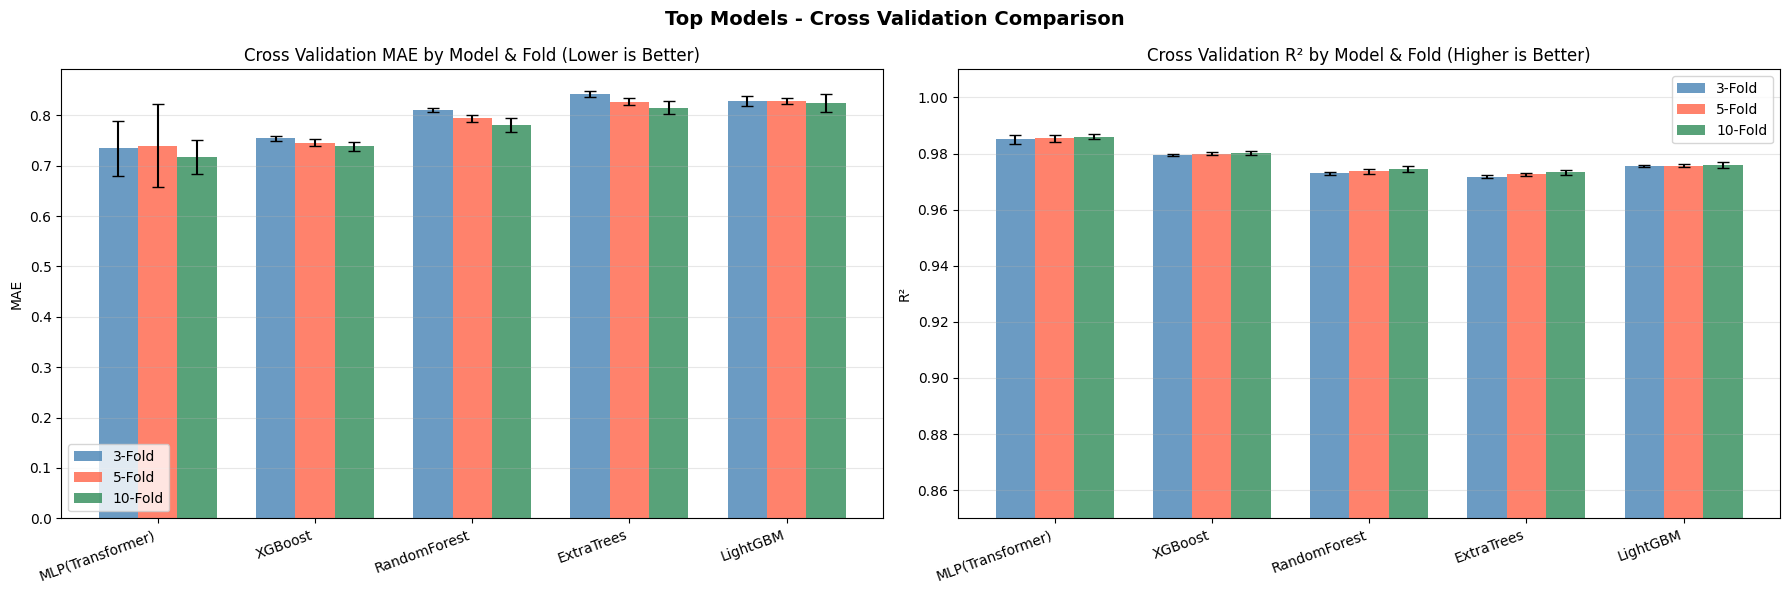


===== Cross Validation Summary Table =====
Model                      CV      MAE        MSE     RMSE       R²
----------------------------------------------------------------------
MLP(Transformer)       3-Fold   0.7343     1.7706   1.3291   0.9850
MLP(Transformer)       5-Fold   0.7393     1.7297   1.3139   0.9854
MLP(Transformer)      10-Fold   0.7172     1.6524   1.2850   0.9860

XGBoost                3-Fold   0.7545     2.4277   1.5581   0.9795
XGBoost                5-Fold   0.7455     2.3736   1.5406   0.9799
XGBoost               10-Fold   0.7384     2.3247   1.5246   0.9803

RandomForest           3-Fold   0.8107     3.1941   1.7872   0.9730
RandomForest           5-Fold   0.7942     3.1057   1.7622   0.9737
RandomForest          10-Fold   0.7809     3.0146   1.7360   0.9745

ExtraTrees             3-Fold   0.8428     3.3361   1.8264   0.9718
ExtraTrees             5-Fold   0.8274     3.2384   1.7995   0.9726
ExtraTrees            10-Fold   0.8153     3.1509   1.7749   0.973

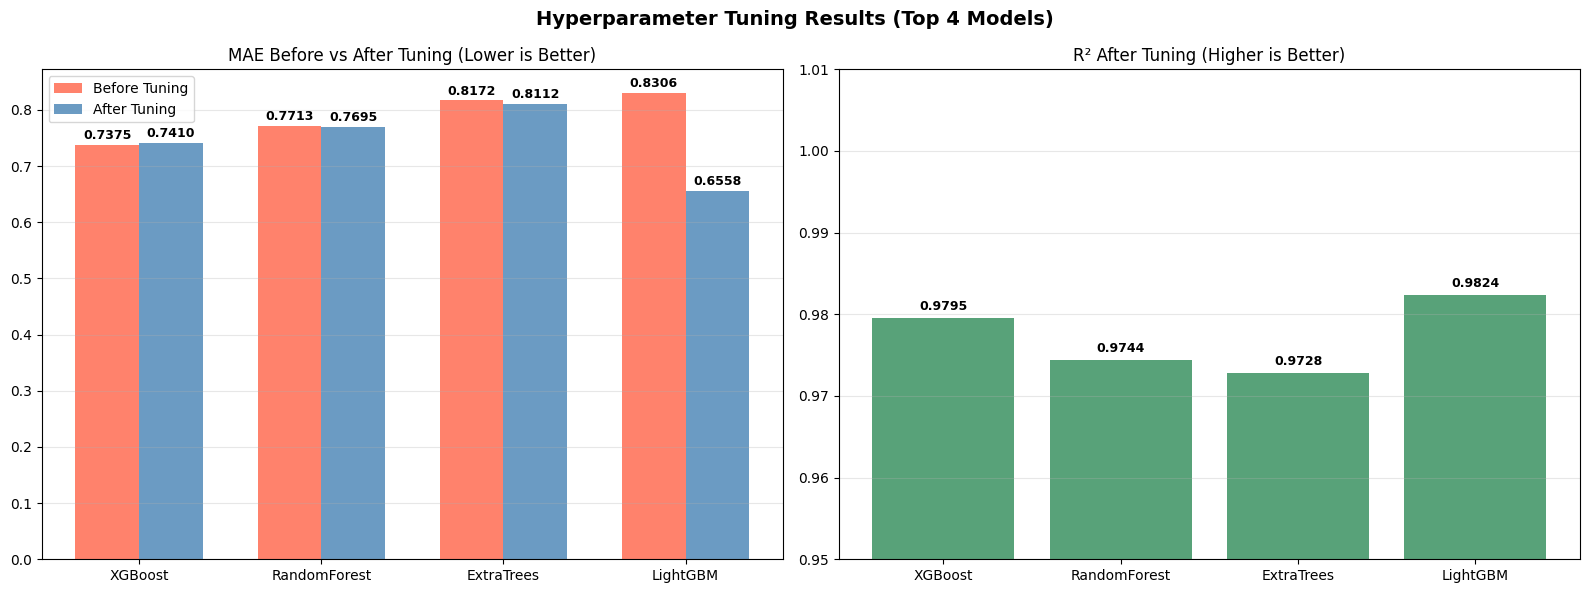


===== Tuning Summary =====
Model             Before MAE  After MAE  After RMSE  After R²  Improvement
---------------------------------------------------------------------------
XGBoost               0.7375     0.7410      1.5245    0.9795      -0.0035
RandomForest          0.7713     0.7695      1.7035    0.9744      +0.0018
ExtraTrees            0.8172     0.8112      1.7572    0.9728      +0.0060
LightGBM              0.8306     0.6558      1.4111    0.9824      +0.1748

✅ Best Model After Tuning: LightGBM
   MAE : 0.6558
   RMSE: 1.4111
   R²  : 0.9824
   Params: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 200, 'max_depth': 20, 'learning_rate': 0.1}


In [ ]:
# =========================
# PART 10. 상위 모델 교차검증 + 하이퍼파라미터 튜닝
# (기존 코드 아래에 별도 실행)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# =========================
# 교차검증 설정
# (3-Fold / 5-Fold / 10-Fold 비교)
# =========================

cv_configs = {
    "3-Fold":  KFold(n_splits=3,  shuffle=True, random_state=42),
    "5-Fold":  KFold(n_splits=5,  shuffle=True, random_state=42),
    "10-Fold": KFold(n_splits=10, shuffle=True, random_state=42),
}

top_models = {
    "MLP(Transformer)": MLPRegressor(
        hidden_layer_sizes=(128, 64), max_iter=500, random_state=42),
    "XGBoost":          XGBRegressor(random_state=42, n_jobs=-1),
    "RandomForest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "ExtraTrees":       ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM":         LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

scaled_top = ["MLP(Transformer)"]

# =========================
# 교차검증 실행
# =========================

print("="*70)
print("Cross Validation Results (3-Fold / 5-Fold / 10-Fold)")
print("="*70)

cv_all_results = {}

for model_name, model in top_models.items():
    print(f"\n----- {model_name} -----")
    X_use = X_train_sc if model_name in scaled_top else X_train

    cv_all_results[model_name] = {}

    for cv_name, cv in cv_configs.items():
        cv_mae  = cross_val_score(model, X_use, y_train, cv=cv,
                                  scoring="neg_mean_absolute_error", n_jobs=-1)
        cv_mse  = cross_val_score(model, X_use, y_train, cv=cv,
                                  scoring="neg_mean_squared_error",  n_jobs=-1)
        cv_r2   = cross_val_score(model, X_use, y_train, cv=cv,
                                  scoring="r2", n_jobs=-1)
        cv_rmse = np.sqrt(-cv_mse)

        cv_all_results[model_name][cv_name] = {
            "MAE":  round(-cv_mae.mean(),  4),
            "MSE":  round(-cv_mse.mean(),  4),
            "RMSE": round(cv_rmse.mean(),  4),
            "R2":   round(cv_r2.mean(),    4),
            "MAE_std": round(cv_mae.std(), 4),
            "R2_std":  round(cv_r2.std(),  4),
        }

        print(f"  [{cv_name}] MAE:{-cv_mae.mean():.4f}±{cv_mae.std():.4f} "
              f"RMSE:{cv_rmse.mean():.4f} R²:{cv_r2.mean():.4f}±{cv_r2.std():.4f}")

# =========================
# 교차검증 결과 시각화
# =========================

# 모델별 / Fold별 MAE 비교
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

model_names = list(top_models.keys())
cv_names    = list(cv_configs.keys())
x = np.arange(len(model_names))
width = 0.25
colors = ["steelblue", "tomato", "seagreen"]

# MAE 비교
for i, (cv_name, color) in enumerate(zip(cv_names, colors)):
    mae_vals = [cv_all_results[m][cv_name]["MAE"] for m in model_names]
    std_vals = [cv_all_results[m][cv_name]["MAE_std"] for m in model_names]
    axes[0].bar(x + i*width, mae_vals, width,
                label=cv_name, color=color, alpha=0.8,
                yerr=std_vals, capsize=4)

axes[0].set_title("Cross Validation MAE by Model & Fold (Lower is Better)")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# R² 비교
for i, (cv_name, color) in enumerate(zip(cv_names, colors)):
    r2_vals  = [cv_all_results[m][cv_name]["R2"]     for m in model_names]
    std_vals = [cv_all_results[m][cv_name]["R2_std"]  for m in model_names]
    axes[1].bar(x + i*width, r2_vals, width,
                label=cv_name, color=color, alpha=0.8,
                yerr=std_vals, capsize=4)

axes[1].set_title("Cross Validation R² by Model & Fold (Higher is Better)")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_ylabel("R²")
axes[1].set_ylim(0.85, 1.01)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Top Models - Cross Validation Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 교차검증 결과 표
print("\n===== Cross Validation Summary Table =====")
print(f"{'Model':<20} {'CV':>8} {'MAE':>8} {'MSE':>10} {'RMSE':>8} {'R²':>8}")
print("-"*70)
for model_name in model_names:
    for cv_name in cv_names:
        r = cv_all_results[model_name][cv_name]
        print(f"{model_name:<20} {cv_name:>8} "
              f"{r['MAE']:>8.4f} {r['MSE']:>10.4f} "
              f"{r['RMSE']:>8.4f} {r['R2']:>8.4f}")
    print()

# =========================
# 하이퍼파라미터 튜닝
# (상위 4개: XGBoost, RF, ExtraTrees, LightGBM)
# MLP는 튜닝 시간이 너무 길어서 제외
# =========================

print("\n" + "="*70)
print("Hyperparameter Tuning (Top 4 Models)")
print("="*70)

param_grids = {
    "XGBoost": {
        "n_estimators":    [100, 200, 300],
        "max_depth":       [3, 5, 7],
        "learning_rate":   [0.05, 0.1, 0.2],
        "subsample":       [0.8, 1.0],
        "colsample_bytree":[0.8, 1.0],
    },
    "RandomForest": {
        "n_estimators":      [100, 200],
        "max_depth":         [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf":  [1, 2],
    },
    "ExtraTrees": {
        "n_estimators":      [100, 200],
        "max_depth":         [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf":  [1, 2],
    },
    "LightGBM": {
        "n_estimators":  [100, 200, 300],
        "max_depth":     [-1, 10, 20],
        "learning_rate": [0.05, 0.1, 0.2],
        "num_leaves":    [31, 63, 127],
        "subsample":     [0.8, 1.0],
    },
}

base_models = {
    "XGBoost":      XGBRegressor(random_state=42, n_jobs=-1),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "ExtraTrees":   ExtraTreesRegressor(random_state=42, n_jobs=-1),
    "LightGBM":     LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

tuning_results = {}

for model_name, model in base_models.items():
    print(f"\n----- {model_name} Tuning -----")

    # 튜닝 전 성능
    model.fit(X_train, y_train)
    y_pred_before = model.predict(X_test)
    before_mae = mean_absolute_error(y_test, y_pred_before)
    before_r2  = r2_score(y_test, y_pred_before)
    print(f"Before → MAE: {before_mae:.4f} | R²: {before_r2:.4f}")

    # RandomizedSearchCV
    rs = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[model_name],
        n_iter=10,
        cv=3,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    rs.fit(X_train, y_train)

    best_model = rs.best_estimator_
    y_pred_after = best_model.predict(X_test)
    after_mae  = mean_absolute_error(y_test, y_pred_after)
    after_rmse = np.sqrt(mean_squared_error(y_test, y_pred_after))
    after_r2   = r2_score(y_test, y_pred_after)

    print(f"After  → MAE: {after_mae:.4f} | R²: {after_r2:.4f}")
    print(f"Best Params: {rs.best_params_}")
    print(f"Improvement: MAE {before_mae - after_mae:+.4f} | R² {after_r2 - before_r2:+.4f}")

    tuning_results[model_name] = {
        "before_mae": round(before_mae, 4),
        "after_mae":  round(after_mae,  4),
        "after_rmse": round(after_rmse, 4),
        "after_r2":   round(after_r2,   4),
        "best_params": rs.best_params_,
        "best_model":  best_model
    }

# =========================
# 튜닝 전/후 비교 시각화
# =========================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names_t = list(tuning_results.keys())
x = np.arange(len(model_names_t))
width = 0.35

before_maes = [tuning_results[m]["before_mae"] for m in model_names_t]
after_maes  = [tuning_results[m]["after_mae"]  for m in model_names_t]
after_r2s   = [tuning_results[m]["after_r2"]   for m in model_names_t]

# MAE 비교
b1 = axes[0].bar(x - width/2, before_maes, width,
                 label="Before Tuning", color="tomato", alpha=0.8)
b2 = axes[0].bar(x + width/2, after_maes, width,
                 label="After Tuning", color="steelblue", alpha=0.8)
for bar, val in zip(b1, before_maes):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01,
                 f"{val:.4f}", ha='center', fontsize=9, fontweight="bold")
for bar, val in zip(b2, after_maes):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01,
                 f"{val:.4f}", ha='center', fontsize=9, fontweight="bold")
axes[0].set_title("MAE Before vs After Tuning (Lower is Better)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_t)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 튜닝 후 R² 비교
bars = axes[1].bar(x, after_r2s, color="seagreen", alpha=0.8)
for bar, val in zip(bars, after_r2s):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.001,
                 f"{val:.4f}", ha='center', fontsize=9, fontweight="bold")
axes[1].set_title("R² After Tuning (Higher is Better)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names_t)
axes[1].set_ylim(0.95, 1.01)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("Hyperparameter Tuning Results (Top 4 Models)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 튜닝 결과 최종 요약 표
print("\n===== Tuning Summary =====")
print(f"{'Model':<15} {'Before MAE':>12} {'After MAE':>10} "
      f"{'After RMSE':>11} {'After R²':>9} {'Improvement':>12}")
print("-"*75)
for m in model_names_t:
    r = tuning_results[m]
    imp = r["before_mae"] - r["after_mae"]
    print(f"{m:<15} {r['before_mae']:>12.4f} {r['after_mae']:>10.4f} "
          f"{r['after_rmse']:>11.4f} {r['after_r2']:>9.4f} {imp:>+12.4f}")

# 최종 최적 모델 선정
best_model_name = min(tuning_results, key=lambda m: tuning_results[m]["after_mae"])
best = tuning_results[best_model_name]
print(f"\n✅ Best Model After Tuning: {best_model_name}")
print(f"   MAE : {best['after_mae']}")
print(f"   RMSE: {best['after_rmse']}")
print(f"   R²  : {best['after_r2']}")
print(f"   Params: {best['best_params']}")

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor

print("🚀 [1단계] 데이터 로드 및 정답(Label) 생성...")
# 1. 데이터 불러오기
df = pd.read_csv('obd_all_merged.csv')

# 2. 운전 위험도 점수(Target) 산출 함수
def calculate_driving_score(row):
    score = 100
    if "SPEED_DIFF" in row:
        accel = max(0, row["SPEED_DIFF"] - 5)
        score -= min(30, accel * 1.5)
        brake = max(0, -row["SPEED_DIFF"] - 5)
        score -= min(30, brake * 1.5)
    if "ENGINE_RPM" in row and row["ENGINE_RPM"] > 2500:
        rpm_excess = (row["ENGINE_RPM"] - 2500) / 100
        score -= min(20, rpm_excess * 2)
    if "SPEED" in row and row["SPEED"] > 80:
        speed_excess = row["SPEED"] - 80
        score -= min(25, speed_excess * 0.5)
    if "SPEED_STD" in row and row["SPEED_STD"] > 5:
        score -= min(15, (row["SPEED_STD"] - 5) * 1.0)
    return max(0, round(score, 1))

df["DRIVING_SCORE"] = df.apply(calculate_driving_score, axis=1)

print("🧹 [2단계] 불필요한 변수 제거 및 결측치 처리...")
# 3. 사용할 피처(X)와 타겟(y) 분리
target_col = "DRIVING_SCORE"
drop_cols = [
    "TIMESTAMP", target_col, "DRIVING_STYLE",
    "HARSH_ACCEL", "HARSH_BRAKE", "HIGH_RPM", "HIGH_SPEED", "IDLING",
    "SPEED_STD",
    "HARSH_ACCEL_CUMSUM", "HARSH_BRAKE_CUMSUM",
    "HIGH_RPM_CUMSUM", "HIGH_SPEED_CUMSUM", "IDLING_CUMSUM",
    "DATA_SOURCE"
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target_col]

# 4. 결측치 처리 (Imputer 학습)
# (주의: 실제 서버에서 새 데이터가 들어올 때도 동일한 Imputer를 사용해야 합니다)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("🧠 [3단계] 최종 최적 모델(LightGBM) 전체 데이터 학습 중...")
# 5. 최종 최적 모델 학습
# 조원의 하이퍼파라미터 튜닝 결과에서 얻은 best_params가 있다면 아래에 인자로 넣어주세요.
# (트리 계열인 LightGBM은 StandardScaler가 필요 없습니다)
model = LGBMRegressor(
    n_estimators=200,    # 예시: 튜닝된 최적 파라미터 적용
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
model.fit(X_imputed, y)

print("📦 [4단계] 모델 및 전처리 파이프라인 파일(.pkl) 저장...")
# 6. 모델 및 환경 객체 저장
joblib.dump(model, 'obd_lgbm_model.pkl')         # 학습된 AI 예측 모델
joblib.dump(imputer, 'obd_imputer.pkl')          # 결측치 채우는 규칙
joblib.dump(list(X.columns), 'obd_features.pkl') # 입력될 피처 순서 (서버 검증용)

print("✅ 성공! 배포용 파일 3개가 현재 디렉토리에 생성되었습니다.")

🚀 [1단계] 데이터 로드 및 정답(Label) 생성...
🧹 [2단계] 불필요한 변수 제거 및 결측치 처리...
🧠 [3단계] 최종 최적 모델(LightGBM) 전체 데이터 학습 중...
📦 [4단계] 모델 및 전처리 파이프라인 파일(.pkl) 저장...
✅ 성공! 배포용 파일 3개가 현재 디렉토리에 생성되었습니다.
